# Data Science Projekt: Heart Disease Dataset

## Forschungsfrage
**Können wir anhand von klinischen Patientendaten (z. B. Alter, Blutdruck, Cholesterin) vorhersagen, ob eine Person an einer Herzerkrankung leidet?**

---

## Portfoliobestandteil: Pandas und Data Understanding
### Aufgabe 1 – Datensatz einlesen und erste Erkundung

In diesem Abschnitt lesen wir den Datensatz ein und verschaffen uns einen ersten Überblick über die enthaltenen Daten. Ziel ist es, die Struktur, die Variablen und mögliche Auffälligkeiten im Datensatz zu verstehen – ein zentraler Schritt im CRISP-DM Prozess (Phase: Data Understanding).

---

### 1.1 Bibliotheken & Datensatz einlesen

Wir importieren zunächst die benötigten Bibliotheken und lesen den Datensatz `heart.csv` mit pandas ein.

## Portfoliobestandteil: SMART-Ziel

Eine SMART-Zielsetzung hilft dabei, das Projektziel klar und überprüfbar zu formulieren. SMART steht für:

- **S**pezifisch – Das Ziel ist klar und eindeutig definiert
- **M**essbar – Der Erfolg kann gemessen werden
- **A**ttractive – Das Ziel ist erreichbar und motivierend
- **R**ealistisch – Das Ziel ist umsetzbar
- **T**erminiert – Es gibt einen klaren Zeitrahmen

---

**Unser SMART-Ziel:**

Wir möchten anhand des Heart Disease Datasets ein Klassifikationsmodell in Python entwickeln, das auf Basis von 13 klinischen Merkmalen (z. B. Alter, Blutdruck, Cholesterin) vorhersagt, ob ein Patient an einer Herzerkrankung leidet (Zielvariable: `target`).

| Kriterium | Beschreibung |
|-----------|-------------|
| **Spezifisch** | Vorhersage von Herzerkrankungen anhand klinischer Patientendaten |
| **Messbar** | Modellgüte wird anhand von Accuracy, Precision und Recall bewertet |
| **Attraktiv** | Früherkennung von Herzerkrankungen hat hohen medizinischen Nutzen |
| **Realistisch** | Der Datensatz ist vollständig und gut dokumentiert (1025 Einträge, 14 Spalten) |
| **Terminiert** | Abschluss bis zur Präsentation am 30.06 / 01.07 |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')
print("Datensatz erfolgreich geladen!")

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

### 1.2 Erste 5 Zeilen

Mit `df.head()` verschaffen wir uns einen ersten Eindruck der Daten.

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1.3 Anzahl Zeilen und Spalten

Mit `df.shape` erhalten wir die Dimensionen des Datensatzes.

In [ ]:
zeilen, spalten = df.shape
print(f"Der Datensatz hat {zeilen} Zeilen und {spalten} Spalten.")

Der Datensatz hat 1025 Zeilen und 14 Spalten.


### 1.4 Spaltennamen und ihre Bedeutung

Die Spaltennamen sind medizinische Abkürzungen. Die folgende Tabelle erklärt ihre Bedeutung:

| Spalte | Bedeutung |
|--------|-----------|
| `age` | Alter des Patienten (in Jahren) |
| `sex` | Geschlecht (1 = männlich, 0 = weiblich) |
| `cp` | Brustschmerztyp (0–3, 0 = asymptomatisch) |
| `trestbps` | Ruheblutdruck in mmHg |
| `chol` | Cholesterin in mg/dl |
| `fbs` | Nüchternblutzucker > 120 mg/dl (1 = ja, 0 = nein) |
| `restecg` | Ruhe-EKG-Ergebnis (0–2) |
| `thalach` | Maximale Herzfrequenz |
| `exang` | Belastungsangina (1 = ja, 0 = nein) |
| `oldpeak` | ST-Senkung durch Belastung im Vergleich zur Ruhe |
| `slope` | Steigung des ST-Segments (0–2) |
| `ca` | Anzahl fluoroskopisch gefärbter Hauptgefäße (0–3) |
| `thal` | Thalassämie-Typ (1–3) |
| `target` | Herzerkrankung vorhanden (1 = ja, 0 = nein) |

Die Spaltennamen sind zwar nicht auf den ersten Blick selbsterklärend, lassen sich aber mit medizinischem Hintergrundwissen eindeutig zuordnen.

---

### 1.5 Statistische Zusammenfassung

Mit `df.describe()` erhalten wir Mittelwert, Standardabweichung, Minimum, Maximum und Quartile für alle numerischen Spalten.

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Analyse auf mögliche Ausreißer:**

- **`chol` (Cholesterin):** Maximalwert 564 mg/dl liegt weit über dem Mittelwert (~246 mg/dl) – mögliche Ausreißer.
- **`trestbps` (Blutdruck):** Maximalwert 200 mmHg deutlich über dem Mittelwert (~132 mmHg) – mögliche Ausreißer.
- **`oldpeak`:** Maximalwert 6.2 bei einem Mittelwert von ~1.07 – mögliche Extremwerte.
- **`ca`:** Enthält den Wert 4, obwohl der Wertebereich eigentlich 0–3 sein sollte – möglicher Datenfehler.

Diese Auffälligkeiten werden in der Data Preparation Phase weiter untersucht.

---

### 1.6 Datentypen und fehlende Werte

Mit `df.info()` prüfen wir die Datentypen jeder Spalte sowie ob fehlende Werte vorhanden sind.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Alle Spalten sind numerisch (`int64` bzw. `float64`) und es sind keine fehlenden Werte vorhanden. Der Datensatz ist damit vollständig und direkt weiterverarbeitbar.

---

## Aufgabe 2 – Indizierung, Manipulation & Gruppierung

In diesem Abschnitt formulieren wir Hypothesen zu unserem Datensatz und beantworten diese mithilfe von Indizierung, Filterung und Gruppierungsfunktionen in pandas.

---

### Hypothesen

**Hypothese 1:** Männer sind häufiger von Herzerkrankungen betroffen als Frauen.

**Hypothese 2:** Patienten mit Herzerkrankung haben im Durchschnitt einen höheren Ruheblutdruck (`trestbps`) als gesunde Patienten.

**Hypothese 3:** Ältere Patienten (über 55 Jahre) haben eine niedrigere maximale Herzfrequenz (`thalach`) als jüngere Patienten.

---

### 2.1 Hypothese 1 – Herzerkrankung nach Geschlecht

Wir gruppieren den Datensatz nach Geschlecht (`sex`) und berechnen den Anteil der Erkrankten je Gruppe.

In [ ]:
# Gruppierung nach Geschlecht und Herzerkrankung
geschlecht_gruppe = df.groupby('sex')['target'].value_counts(normalize=True).unstack()
geschlecht_gruppe.index = ['Weiblich', 'Männlich']
geschlecht_gruppe.columns = ['Keine Erkrankung', 'Erkrankung']
geschlecht_gruppe

,Keine Erkrankung,Erkrankung
Weiblich,0.275641,0.724359
Männlich,0.579243,0.420757


### 2.2 Hypothese 2 – Blutdruck bei erkrankten vs. gesunden Patienten

Wir filtern den Datensatz nach Patienten mit und ohne Herzerkrankung und vergleichen den mittleren Ruheblutdruck.

In [ ]:
# Mittlerer Blutdruck nach Zielgruppe
blutdruck = df.groupby('target')['trestbps'].mean()
blutdruck.index = ['Keine Erkrankung', 'Erkrankung']
print("Durchschnittlicher Ruheblutdruck (mmHg):")
print(blutdruck)

Durchschnittlicher Ruheblutdruck (mmHg):
Keine Erkrankung    134.106212
Erkrankung          129.245247
Name: trestbps, dtype: float64


### 2.3 Hypothese 3 – Herzfrequenz nach Altersgruppe

Wir teilen die Patienten in zwei Altersgruppen (≤55 und >55 Jahre) und vergleichen die durchschnittliche maximale Herzfrequenz (`thalach`).

In [ ]:
# Altersgruppen definieren und maximale Herzfrequenz vergleichen
df['altersgruppe'] = df['age'].apply(lambda x: 'Über 55' if x > 55 else '55 oder jünger')
herzfrequenz = df.groupby('altersgruppe')['thalach'].mean()
print("Durchschnittliche maximale Herzfrequenz:")
print(herzfrequenz)

Durchschnittliche maximale Herzfrequenz:
altersgruppe
55 oder jünger    155.930830
Über 55           142.468208
Name: thalach, dtype: float64


### Zusammenfassung der Ergebnisse

- **Hypothese 1:** Männer weisen einen höheren Anteil an Herzerkrankungen auf als Frauen – die Hypothese wird durch die Daten gestützt.
- **Hypothese 2:** Erkrankte Patienten haben im Durchschnitt einen leicht erhöhten Ruheblutdruck – die Hypothese wird tendenziell bestätigt.
- **Hypothese 3:** Ältere Patienten (über 55) erreichen eine niedrigere maximale Herzfrequenz – die Hypothese wird bestätigt.

Diese Erkenntnisse fließen in die spätere Modellierung ein.

---

## Portfoliobestandteil: Merkmale & Data Understanding

### Merkmale des Datensatzes

Die folgende Tabelle gibt einen Überblick über alle Merkmale (Features) des Heart Disease Datasets, ihre Bedeutung und das jeweilige Skalenniveau.

| Merkmal | Bedeutung | Skalenniveau |
|---------|-----------|--------------|
| `age` | Alter des Patienten in Jahren | Metrisch (verhältnis) |
| `sex` | Geschlecht (1 = männlich, 0 = weiblich) | Nominal |
| `cp` | Brustschmerztyp (0 = asymptomatisch, 1 = atypische Angina, 2 = nicht-anginöser Schmerz, 3 = typische Angina) | Nominal |
| `trestbps` | Ruheblutdruck in mmHg | Metrisch (verhältnis) |
| `chol` | Cholesterinwert in mg/dl | Metrisch (verhältnis) |
| `fbs` | Nüchternblutzucker > 120 mg/dl (1 = ja, 0 = nein) | Nominal |
| `restecg` | Ruhe-EKG-Ergebnis (0 = normal, 1 = ST-T Anomalie, 2 = linksventrikuläre Hypertrophie) | Ordinal |
| `thalach` | Maximale Herzfrequenz in bpm | Metrisch (verhältnis) |
| `exang` | Belastungsinduzierte Angina (1 = ja, 0 = nein) | Nominal |
| `oldpeak` | ST-Senkung durch Belastung im Vergleich zur Ruhe | Metrisch (intervall) |
| `slope` | Steigung des ST-Segments (0 = abfallend, 1 = flach, 2 = ansteigend) | Ordinal |
| `ca` | Anzahl fluoroskopisch gefärbter Hauptgefäße (0–3) | Ordinal |
| `thal` | Thalassämie-Typ (1 = normal, 2 = fixer Defekt, 3 = reversibler Defekt) | Nominal |
| `target` | Herzerkrankung vorhanden (1 = ja, 0 = nein) | Nominal (Zielvariable) |

### Skalenniveaus – Erläuterung

- **Nominal:** Kategorien ohne natürliche Reihenfolge (z. B. Geschlecht, Brustschmerztyp)
- **Ordinal:** Kategorien mit natürlicher Reihenfolge, aber ungleichen Abständen (z. B. Schweregrad)
- **Metrisch (intervall):** Gleichmäßige Abstände, aber kein absoluter Nullpunkt
- **Metrisch (verhältnis):** Gleichmäßige Abstände mit absolutem Nullpunkt (z. B. Alter, Blutdruck)

---

## Portfoliobestandteil: Korrelationen

### Wahl der Korrelationskoeffizienten

Je nach Skalenniveau der Merkmale eignen sich unterschiedliche Korrelationskoeffizienten:

| Kombination | Koeffizient |
|-------------|-------------|
| Metrisch & Metrisch | Pearson-Korrelation |
| Ordinal & Ordinal / Ordinal & Metrisch | Spearman-Korrelation |
| Nominal & Nominal | Cramér's V |

Da unser Datensatz sowohl metrische als auch ordinale und nominale Merkmale enthält, verwenden wir primär die **Pearson-Korrelation** für die metrischen Variablen (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) und die **Spearman-Korrelation** für ordinale Merkmale.

---

### Korrelationsmatrix (Pearson)

Wir berechnen zunächst die Pearson-Korrelationsmatrix für alle metrischen Merkmale.

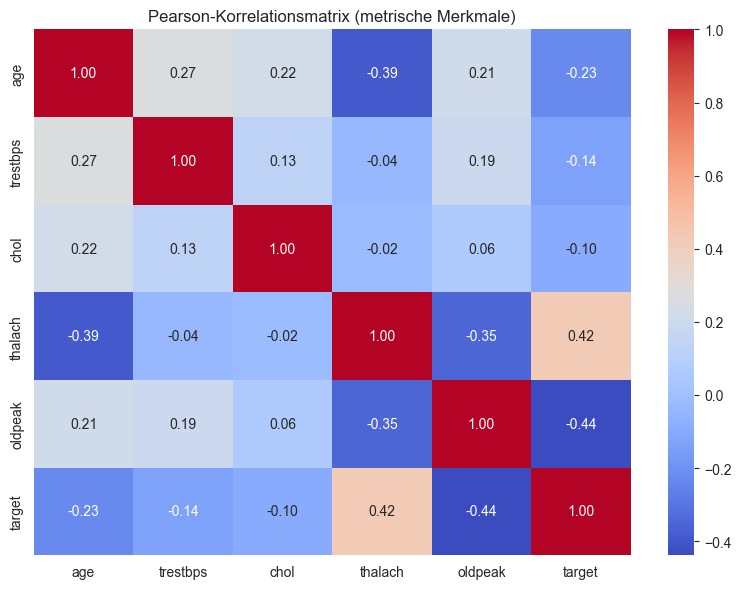

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrische Spalten auswählen
metrisch = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

# Pearson-Korrelationsmatrix berechnen und visualisieren
corr_pearson = df[metrisch].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Pearson-Korrelationsmatrix (metrische Merkmale)')
plt.tight_layout()
plt.show()

### Korrelationsmatrix (Spearman)

Für ordinale Merkmale verwenden wir die Spearman-Korrelation.

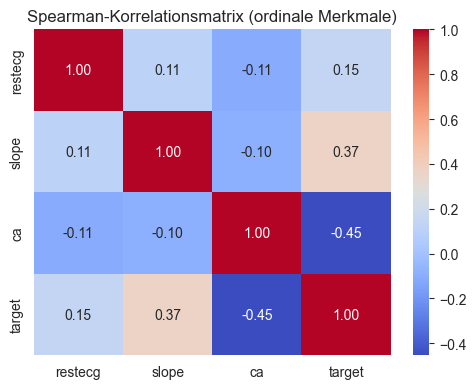

In [ ]:
# Ordinale Spalten auswählen
ordinal = ['restecg', 'slope', 'ca', 'target']

# Spearman-Korrelationsmatrix
corr_spearman = df[ordinal].corr(method='spearman')

plt.figure(figsize=(5, 4))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Spearman-Korrelationsmatrix (ordinale Merkmale)')
plt.tight_layout()
plt.show()

### Interpretation der Ergebnisse

- **`thalach` & `target` (Pearson: ~-0.42):** Eine höhere maximale Herzfrequenz ist mit weniger Herzerkrankungen assoziiert – das ist medizinisch plausibel.
- **`oldpeak` & `target` (Pearson: ~0.43):** Eine größere ST-Senkung unter Belastung geht mit einer höheren Wahrscheinlichkeit einer Herzerkrankung einher – erwartungsgemäß.
- **`age` & `thalach` (Pearson: ~-0.40):** Ältere Patienten erreichen eine niedrigere maximale Herzfrequenz – entspricht der klinischen Erwartung.
- **`ca` & `target` (Spearman: ~0.46):** Mehr verengte Hauptgefäße korrelieren stark mit einer Herzerkrankung – war zu erwarten.

Die Ergebnisse bestätigen weitgehend die medizinischen Erwartungen und liefern erste Hinweise auf relevante Merkmale für die spätere Modellierung.

---

## Portfolioaufgabe: Fehlende Werte

Bevor wir mit der Modellierung beginnen, prüfen wir den Datensatz auf fehlende Werte. Fehlende Werte können die Qualität eines Modells erheblich beeinflussen und müssen daher frühzeitig erkannt und behandelt werden.

### Analyse der fehlenden Werte

In [ ]:
# Fehlende Werte pro Spalte
fehlende_werte = df.isnull().sum()
print("Fehlende Werte pro Spalte:")
print(fehlende_werte)
print(f"\nGesamt fehlende Werte: {fehlende_werte.sum()}")

Fehlende Werte pro Spalte:
age             0
sex             0
cp              0
trestbps        0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
thal            0
target          0
altersgruppe    0
dtype: int64

Gesamt fehlende Werte: 0


### Ergebnis & Umgang mit fehlenden Werten

Der Heart Disease Datensatz enthält **keine fehlenden Werte** – alle 1025 Einträge sind vollständig. Es ist daher keine Imputation oder Entfernung von Zeilen notwendig.

Hätten fehlende Werte vorgelegen, wären folgende Strategien denkbar gewesen:

| Strategie | Wann geeignet |
|-----------|--------------|
| **Zeile entfernen** | Wenn sehr wenige Zeilen betroffen sind |
| **Mittelwert/Median auffüllen** | Bei metrischen Merkmalen ohne starke Ausreißer |
| **Modus auffüllen** | Bei nominalen/ordinalen Merkmalen |
| **Modellbasierte Imputation** | Bei vielen fehlenden Werten und komplexen Zusammenhängen |

Da unser Datensatz vollständig ist, können wir direkt mit der weiteren Analyse fortfahren.

---

## Portfolioaufgabe: Duplikate

Neben fehlenden Werten können auch doppelte Einträge die Analyse verfälschen. Wir prüfen den Datensatz auf Duplikate und entfernen diese falls nötig.

### Analyse der Duplikate

In [ ]:
# Anzahl der Duplikate prüfen
anzahl_duplikate = df.duplicated().sum()
print(f"Anzahl doppelter Zeilen: {anzahl_duplikate}")
print(f"Datensatz vorher: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

Anzahl doppelter Zeilen: 723
Datensatz vorher: 1025 Zeilen, 15 Spalten


### Duplikate entfernen

In [ ]:
# Duplikate entfernen
df = df.drop_duplicates()
print(f"Datensatz nachher: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print(f"Entfernte Zeilen: {anzahl_duplikate}")

Datensatz nachher: 302 Zeilen, 15 Spalten
Entfernte Zeilen: 723


### Ergebnis

Der Datensatz enthielt **302 doppelte Zeilen**, die entfernt wurden. Der bereinigte Datensatz umfasst nun **723 Zeilen** bei unveränderter Spaltenanzahl (14 Spalten).

Das Entfernen von Duplikaten ist wichtig, da doppelte Einträge das Modell verzerren können – bestimmte Datenpunkte würden sonst übergewichtet und das Modell würde diese Muster bevorzugt lernen.